In [ ]:
# import the packages
import geopandas as gpd
import glob
import os
from osgeo import ogr
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt

THIS CODE BELOW DISPLAYS POINTS SHAPEFFILE: THERE IS A FIELD IN THE ATTRIBUTE TABLE OF THE SHAPEFILE THAT
STORES FLOODED (1) AND NOTFLOODED (1). THE FIELD IS CALLED "FLORNOFL"

<Axes: >

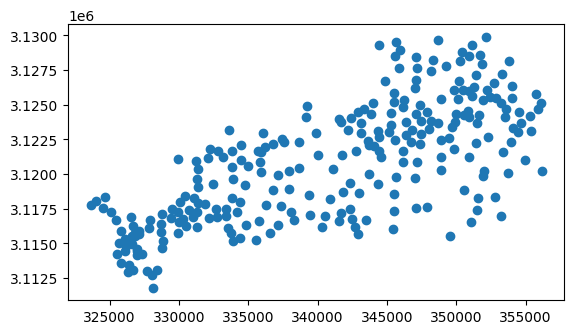

In [ ]:
# # read the points shape file using geopandas and plot the points
# points = gpd.read_file(r"C:\Users\user\Desktop\THESIS FOCUS\ML\CNN\Points.shp")
# points.plot()
import geopandas as gpd

# Read shapefile using pyogrio instead of fiona
points = gpd.read_file(r"/content/drive/MyDrive/CNN_262/Points_262.shp", engine="pyogrio")

# Plot the points
points.plot()



THIS SNIPPET BELOW CONVERTS THE POINTS TO POLYGONS BY CREATING A BUFFER AROUND
THE POINTS

In [ ]:
buffer_dist=50 #buffer distance = image size x spatial resolution /2

# Read in the shapefile
points = gpd.read_file(r"/content/drive/MyDrive/CNN_262/Points_262.shp")

# Create square buffers with a side length of buffer_dist units around the point features
points['geometry'] = points.buffer(buffer_dist)

points['geometry'] = points.geometry.envelope

# Define the output file path
output_path = r"/content/drive/MyDrive/CNN_262/squares.shp"

# Save the new shapefile
points.to_file(output_path)

print(f"Shapefile saved successfully at: {output_path}")



Shapefile saved successfully at: /content/drive/MyDrive/CNN_262/squares.shp


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field EVENTDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field RECORDEDDA create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field SURVEYDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field created_da create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field last_edi_1 create as date field, though DateTime requested.
  ogr_write(


<Axes: >

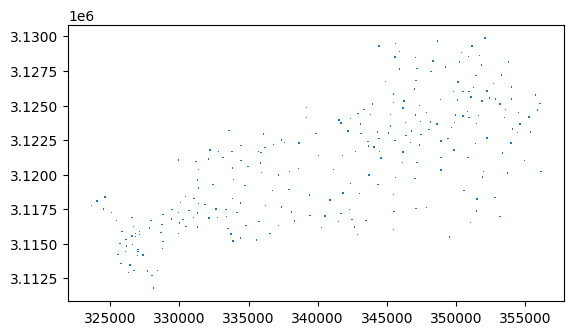

In [ ]:
# Read the saved shapefile to confirm it was written correctly
squares = gpd.read_file(output_path)
# Print the first few rows of the shapefile
#print(squares)
# Plot the shapefile to visualize the squares
squares.plot()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

THIS SNIPPET USES THE POLYGON SHAPEFILE (squares) TO CREATE A SEPARATE SHAPEFILE FOR EACH
BUFFERED POINT WITHIN THE SHAPEFILE. SINCE THERE 80 BUFFERED POINTS, THERE WILL BE 80 SHAPEFILES
AFTER RUNNING THIS CODE BELOW, AND THEY WILL BE STORED IN A FOLDER CALLED "Divided"

In [ ]:
# Split the flooded and nonflooded points
#points_flooded=points[points['Label']==1]
#points_notflooded=points[points['Label']==0]

# Iterate over each feature in the shapefile
for index, feature in points.iterrows():
    # Create a new GeoDataFrame with just the current feature
    #print(index)

    feature_gdf = points.iloc[[index]]
    #print(feature_gdf)
    #print(feature_gdf['Label'][index])



    # Save the feature to a new shapefile
    feature_gdf.to_file(r"/content/drive/MyDrive/CNN_262/Divided\feature_{}.shp".format(index))

/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field EVENTDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field RECORDEDDA create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field SURVEYDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field created_da create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field last_edi_1 create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field EVENTDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarni

I CREATED A RASTER FILE CALLED "Composite_rasters.tif" BY COMBINING FOUR VARIABLES
VARIABLES: DEM, LANDUSE, INFILTRATION, RAINFALL. EACH VARIABLE WILL REPRESENT ONE BAND IN
THE Coomposite_rasters.tif FILE

THIS SNIPPET BELOW JUST READS THE SEPARATE BANDS AS WELL AS PROJECTION DETAILS OF
THE Composite_rasters.tif FILE AS WELL  AS ITS

Raster successfully loaded!
Number of Bands: 4
GeoTransform: (323169.6500972328, 10.0, 0.0, 3130223.0019000005, 0.0, -10.0)
Projection: PROJCS["NAD83 / UTM zone 17N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26917"]]

DEM: Min=-3.4028234663852886e+38, Max=28.0, Mean=-inf

Landuse: Min=1.0, Max=15.0, Mean=10.97564697265625

Infiltration: Min=-3.4028234663852886e+38, Max=100.0, Mean=-inf

Rainfall: Min=-3.4028234663852886e+38, Max=63.86410140991211, Mean=-inf


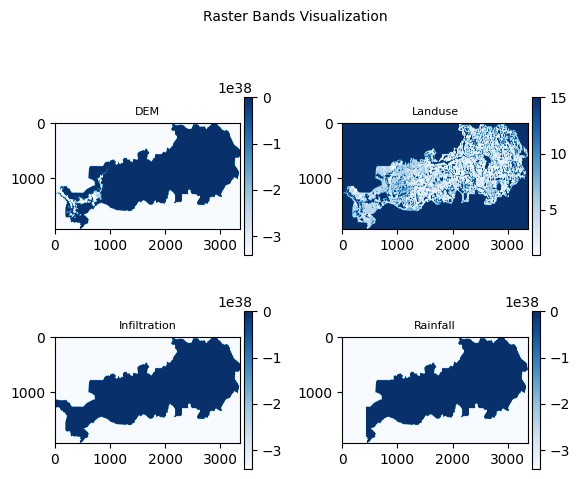

In [ ]:
import os
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np

raster_path = r"/content/drive/MyDrive/CNN_262/Composite_rasters.tif"

# Open the raster file
ds = gdal.Open(raster_path)

# Check if the raster was loaded correctly
if ds is None:
    raise ValueError(f"Error: Could not open the raster file at {raster_path}")

# Get spatial metadata
gt = ds.GetGeoTransform()  # Georeferencing information
proj = ds.GetProjection()   # Projection information
num_bands = ds.RasterCount  # Number of bands in the raster

print(f"Raster successfully loaded!")
print(f"Number of Bands: {num_bands}")
print(f"GeoTransform: {gt}")
print(f"Projection: {proj}")

# Define band names
band_names = ["DEM", "Landuse", "Infiltration", "Rainfall"]

if num_bands != len(band_names):
    raise ValueError("Number of bands does not match the expected band names.")

# Create a 2x2 plot layout with smaller figure size
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
fig.suptitle("Raster Bands Visualization", fontsize=10)

# Loop over all bands and visualize them
for i, band_num in enumerate(range(1, num_bands + 1)):
    band = ds.GetRasterBand(band_num)  # Read band
    array = band.ReadAsArray()  # Convert band to numpy array

    # Print statistics
    print(f"\n{band_names[i]}: Min={np.min(array)}, Max={np.max(array)}, Mean={np.mean(array)}")

    # Determine subplot position
    row, col = divmod(i, 2)
    ax = axes[row, col]

    # Plot each band
    img = ax.imshow(array, cmap='Blues')  # Use 'Blues' for better contrast
    ax.set_title(band_names[i], fontsize=8)
    fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.04, pad=0.02)

# Adjust layout for compact display
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



A FOLDER CALLED "Predictive_features" IS CREATED. TWO FOLDERS "Flooded and NotFlooded" ARE CREATED

THE SNIPPET BELOW USES THE 80 POLYGON SHAPEFILES CREATED EARLIER TO CLIP THE Compositer_raster.tif IMAGE
THE RESULTING CLIPS ARE .tif FILES AND THEY ARE SEPARATED INTO COREPONDING FOLDERS ACCORDING TO
EITHER THE PARTICULAR POLYGON IS LABELED FLOODED OR NOTFLOODED

In [ ]:
# change the path to the folder where we saved the splitted polygons
shp_path=r"/content/drive/MyDrive/CNN_262/Divided"
os.chdir(shp_path)
shp_file = glob.glob('*.shp')
#index =0
for file in shp_file:
        #print(str(file))
        ds2 = ogr.Open(file, 1)
        layer = ds2.GetLayer()
        shp_ds=gpd.read_file(file)
        #print(shp_ds['Label'][0])
        #index+=1
        # we will clip the raster with each polygon and save the flooded and notflooded locations in different folders
        # we will check the label, if label =0 then this is not flooded location
        # Label = 0 for non-flooded locations, Label = 1 for flooded locations
        if shp_ds['FLORNOFL'][0] == 0 : # clip and save not flooded locations
             #Save the feature to a new shapefile
            dsClip = gdal.Warp(r"/content/drive/MyDrive/CNN_262/Predictive_features/NotFlooded/feature_"+str(file[:-4])+".tif", ds, cutlineDSName = file,
                       cropToCutline = True, dstNodata = np.nan)
        else: # clip and save flooded locations
            # Save the feature to a new shapefile

            dsClip = gdal.Warp(r"/content/drive/MyDrive/CNN_262/Predictive_features/Flooded/feature_"+str(file[:-4])+".tif", ds, cutlineDSName = file,
                       cropToCutline = True, dstNodata = np.nan)

**NOW MODEL TRAINING BEGINS**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os
import cv2
#import keras
#from keras.utils import normalize
#from keras import *
import pandas as pd

***Read the data and prepare it for the model***

In [ ]:
# Read the preditive features and the label (Notflooded=0 , flooded=1)
data_path=r"/content/drive/MyDrive/CNN_262/Predictive_features/" # created in data_preperation script
CATEGORIES= ["NotFlooded", "Flooded"]

In [ ]:
IMG_SIZE=10

***THIS SNIPPET READS AND PRINTS THE FIRST CLIPPED IMAGE FROM THE NotFlooded Folder***

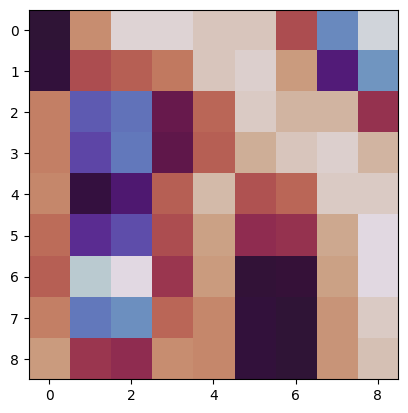

In [ ]:
# Check the images
# plot the first band in the first image
for category in CATEGORIES:
    path=os.path.join(data_path,category) # Path to flooded and NotFlooded dir
    for img in os.listdir(path):
        img_open=rasterio.open(os.path.join(path,img))
        img_array=img_open.read(1) # open the image and read the band
        img_array= np.where(img_array < 0, np.nan,img_array)
        mean=np.nanmean(img_array)
        img_array= np.where(np.isnan(img_array), mean,img_array)
        plt.imshow(img_array,cmap="twilight")
        plt.show()
        #print(img_array)
        break
    break

In [ ]:
for i in range(1,5):
    print(i)

1
2
3
4


THIS SNIPPET BELOW SAVES THE FOUR VARIABLES TO BE USED FOR THE TRAINING

In [ ]:
# Create empty lists for each predictive feature
DEM = []
Landuse = []
Infiltration = []
Rainfall = []
y = []  # Labels (0 = NotFlooded, 1 = Flooded)


# Store them in a list in the same order as the bands in the raster images
predictive_features = [DEM, Landuse, Infiltration, Rainfall]
print(len(predictive_features))

4


In [ ]:
def create_training_data():
    for i in range(len(predictive_features)):
        print(i+1)
        for category in CATEGORIES:
            path= os.path.join(data_path,category) # Path to flooded and NotFlooded dir
            class_num= CATEGORIES.index(category)
            for img in os.listdir(path):
                try:
                    img_open=rasterio.open(os.path.join(path,img))
                    print(category,img,class_num)
                    img_array=img_open.read(i+1)
                    #img_array= np.where(img_array < 0, np.nan,img_array)
                    #mean=np.nanmean(img_array)
                    #img_array= np.where(np.isnan(img_array), mean,img_array)
                    #new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))  # resize to normalize data size
                    predictive_features[i].append(img_array)

                    if i==0:
                        y.append(class_num)
                        #print(class_num)
                except Exception as e:
                    pass
create_training_data()

1
NotFlooded feature_feature_12.tif 0
NotFlooded feature_feature_13.tif 0
NotFlooded feature_feature_16.tif 0
NotFlooded feature_feature_17.tif 0
NotFlooded feature_feature_19.tif 0
NotFlooded feature_feature_24.tif 0
NotFlooded feature_feature_26.tif 0
NotFlooded feature_feature_27.tif 0
NotFlooded feature_feature_28.tif 0
NotFlooded feature_feature_30.tif 0
NotFlooded feature_feature_31.tif 0
NotFlooded feature_feature_33.tif 0
NotFlooded feature_feature_34.tif 0
NotFlooded feature_feature_36.tif 0
NotFlooded feature_feature_37.tif 0
NotFlooded feature_feature_39.tif 0
NotFlooded feature_feature_40.tif 0
NotFlooded feature_feature_41.tif 0
NotFlooded feature_feature_42.tif 0
NotFlooded feature_feature_44.tif 0
NotFlooded feature_feature_46.tif 0
NotFlooded feature_feature_47.tif 0
NotFlooded feature_feature_48.tif 0
NotFlooded feature_feature_49.tif 0
NotFlooded feature_feature_50.tif 0
NotFlooded feature_feature_64.tif 0
NotFlooded feature_feature_65.tif 0
NotFlooded feature_feature

Flooded feature_feature_58.tif 1
Flooded feature_feature_59.tif 1
Flooded feature_feature_60.tif 1
Flooded feature_feature_61.tif 1
Flooded feature_feature_62.tif 1
Flooded feature_feature_63.tif 1
Flooded feature_feature_66.tif 1
Flooded feature_feature_67.tif 1
Flooded feature_feature_68.tif 1
Flooded feature_feature_70.tif 1
Flooded feature_feature_71.tif 1
Flooded feature_feature_72.tif 1
Flooded feature_feature_73.tif 1
Flooded feature_feature_74.tif 1
Flooded feature_feature_77.tif 1
Flooded feature_feature_81.tif 1
Flooded feature_feature_82.tif 1
Flooded feature_feature_83.tif 1
Flooded feature_feature_86.tif 1
Flooded feature_feature_87.tif 1
Flooded feature_feature_93.tif 1
Flooded feature_feature_94.tif 1
Flooded feature_feature_95.tif 1
Flooded feature_feature_100.tif 1
Flooded feature_feature_101.tif 1
Flooded feature_feature_102.tif 1
Flooded feature_feature_108.tif 1
Flooded feature_feature_110.tif 1
Flooded feature_feature_112.tif 1
Flooded feature_feature_115.tif 1
Flo

Flooded feature_feature_58.tif 1
Flooded feature_feature_59.tif 1
Flooded feature_feature_60.tif 1
Flooded feature_feature_61.tif 1
Flooded feature_feature_62.tif 1
Flooded feature_feature_63.tif 1
Flooded feature_feature_66.tif 1
Flooded feature_feature_67.tif 1
Flooded feature_feature_68.tif 1
Flooded feature_feature_70.tif 1
Flooded feature_feature_71.tif 1
Flooded feature_feature_72.tif 1
Flooded feature_feature_73.tif 1
Flooded feature_feature_74.tif 1
Flooded feature_feature_77.tif 1
Flooded feature_feature_81.tif 1
Flooded feature_feature_82.tif 1
Flooded feature_feature_83.tif 1
Flooded feature_feature_86.tif 1
Flooded feature_feature_87.tif 1
Flooded feature_feature_93.tif 1
Flooded feature_feature_94.tif 1
Flooded feature_feature_95.tif 1
Flooded feature_feature_100.tif 1
Flooded feature_feature_101.tif 1
Flooded feature_feature_102.tif 1
Flooded feature_feature_108.tif 1
Flooded feature_feature_110.tif 1
Flooded feature_feature_112.tif 1
Flooded feature_feature_115.tif 1
Flo

Flooded feature_feature_61.tif 1
Flooded feature_feature_62.tif 1
Flooded feature_feature_63.tif 1
Flooded feature_feature_66.tif 1
Flooded feature_feature_67.tif 1
Flooded feature_feature_68.tif 1
Flooded feature_feature_70.tif 1
Flooded feature_feature_71.tif 1
Flooded feature_feature_72.tif 1
Flooded feature_feature_73.tif 1
Flooded feature_feature_74.tif 1
Flooded feature_feature_77.tif 1
Flooded feature_feature_81.tif 1
Flooded feature_feature_82.tif 1
Flooded feature_feature_83.tif 1
Flooded feature_feature_86.tif 1
Flooded feature_feature_87.tif 1
Flooded feature_feature_93.tif 1
Flooded feature_feature_94.tif 1
Flooded feature_feature_95.tif 1
Flooded feature_feature_100.tif 1
Flooded feature_feature_101.tif 1
Flooded feature_feature_102.tif 1
Flooded feature_feature_108.tif 1
Flooded feature_feature_110.tif 1
Flooded feature_feature_112.tif 1
Flooded feature_feature_115.tif 1
Flooded feature_feature_116.tif 1
Flooded feature_feature_121.tif 1
Flooded feature_feature_122.tif 1


Flooded feature_feature_52.tif 1
Flooded feature_feature_53.tif 1
Flooded feature_feature_54.tif 1
Flooded feature_feature_55.tif 1
Flooded feature_feature_56.tif 1
Flooded feature_feature_57.tif 1
Flooded feature_feature_58.tif 1
Flooded feature_feature_59.tif 1
Flooded feature_feature_60.tif 1
Flooded feature_feature_61.tif 1
Flooded feature_feature_62.tif 1
Flooded feature_feature_63.tif 1
Flooded feature_feature_66.tif 1
Flooded feature_feature_67.tif 1
Flooded feature_feature_68.tif 1
Flooded feature_feature_70.tif 1
Flooded feature_feature_71.tif 1
Flooded feature_feature_72.tif 1
Flooded feature_feature_73.tif 1
Flooded feature_feature_74.tif 1
Flooded feature_feature_77.tif 1
Flooded feature_feature_81.tif 1
Flooded feature_feature_82.tif 1
Flooded feature_feature_83.tif 1
Flooded feature_feature_86.tif 1
Flooded feature_feature_87.tif 1
Flooded feature_feature_93.tif 1
Flooded feature_feature_94.tif 1
Flooded feature_feature_95.tif 1
Flooded feature_feature_100.tif 1
Flooded f

CHECK IMAGE SIZE

In [ ]:
np.shape(DEM[0]) # check image size

(9, 9)

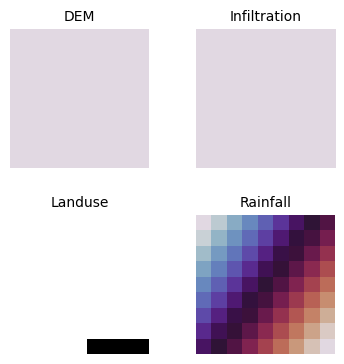

In [ ]:
# Create a 2x2 grid for subplots with a smaller figure size
fig, axes = plt.subplots(2, 2, figsize=(4, 4))  # Adjust figsize for smaller plots

# Plot each image in its respective subplot
axes[0, 0].imshow(DEM[10], cmap="twilight")
axes[0, 0].set_title("DEM", fontsize=10)
axes[0, 0].axis("off")  # Hide axes

axes[0, 1].imshow(Landuse[0], cmap="twilight")
axes[0, 1].set_title("Infiltration", fontsize=10)
axes[0, 1].axis("off")

axes[1, 0].imshow(Infiltration[10], cmap="bone_r")
axes[1, 0].set_title("Landuse", fontsize=10)
axes[1, 0].axis("off")

axes[1, 1].imshow(Rainfall[4], cmap="twilight")
axes[1, 1].set_title("Rainfall", fontsize=10)
axes[1, 1].axis("off")

# Adjust layout to prevent overlap
plt.tight_layout(pad=2)  # Reduce padding slightly
plt.show()

In [ ]:
# check the number of images
a = [len(DEM), len(Landuse), len(Infiltration), len(Rainfall)]
print(a)

[262, 262, 262, 262]


In [ ]:
print(f"DEM Shape Before: {np.array(DEM).shape}")
print(f"Landuse Shape Before: {np.array(Landuse).shape}")
print(f"Infiltration Shape Before: {np.array(Infiltration).shape}")
print(f"Rainfall Shape Before: {np.array(Rainfall).shape}")

I INITIALLY SET THE IMG_SIZE TO 10, SO THE CODE DID NOT WORK BECAUSE
ALL THE VARIABLES HAVE 80 X 59 X 59 IN SIZE. SO THE CODE SNIPPET JUST BELOW WORKS
ONLY WHEN IMG_SIZE IS SET TO 59 (WHICH IS THE SAME SIZE AS THE VARIABLES)

In [ ]:
# # Convert feature lists to NumPy arrays and reshape
# DEM_array = np.array(DEM).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
# Landuse_array = np.array(Landuse).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
# Infiltration_array = np.array(Infiltration).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
# Rainfall_array = np.array(Rainfall).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Get the correct shape of the images in the DEM list
image_shape = DEM[0].shape  # Assuming all images in DEM have the same shape

# Calculate the number of images based on the total size and image shape
num_images = len(DEM)

# Before reshaping, replace NaN values in the individual feature lists
# ✅ Calculate mean for each image individually
# ✅ Ensure all images have consistent dimensions before reshaping

consistent_shape = image_shape  # Set initial shape for comparison

# ✅ Check and resize if necessary
for i in range(len(DEM)):
    if DEM[i].shape != consistent_shape:
        DEM[i] = cv2.resize(DEM[i], (consistent_shape[1], consistent_shape[0]))  # Resize to consistent shape
    if Landuse[i].shape != consistent_shape:
        Landuse[i] = cv2.resize(Landuse[i], (consistent_shape[1], consistent_shape[0]))  # Resize to consistent shape
    if Infiltration[i].shape != consistent_shape:
        Infiltration[i] = cv2.resize(Infiltration[i], (consistent_shape[1], consistent_shape[0]))  # Resize to consistent shape
    if Rainfall[i].shape != consistent_shape:
        Rainfall[i] = cv2.resize(Rainfall[i], (consistent_shape[1], consistent_shape[0]))  # Resize to consistent shape

    DEM[i] = np.nan_to_num(DEM[i], nan=np.nanmean(DEM[i]))
    Landuse[i] = np.nan_to_num(Landuse[i], nan=np.nanmean(Landuse[i]))
    Infiltration[i] = np.nan_to_num(Infiltration[i], nan=np.nanmean(Infiltration[i]))
    Rainfall[i] = np.nan_to_num(Rainfall[i], nan=np.nanmean(Rainfall[i]))


# Then proceed with reshaping and model fitting as usual

# Reshape with the correct dimensions
DEM_array = np.array(DEM).reshape(num_images, image_shape[0], image_shape[1], 1)
Landuse_array = np.array(Landuse).reshape(num_images, image_shape[0], image_shape[1], 1)
Infiltration_array = np.array(Infiltration).reshape(num_images, image_shape[0], image_shape[1], 1)
Rainfall_array = np.array(Rainfall).reshape(num_images, image_shape[0], image_shape[1], 1)

<ipython-input-25-b1597f3b874a>:33: RuntimeWarning: Mean of empty slice
  Rainfall[i] = np.nan_to_num(Rainfall[i], nan=np.nanmean(Rainfall[i]))
<ipython-input-25-b1597f3b874a>:30: RuntimeWarning: Mean of empty slice
  DEM[i] = np.nan_to_num(DEM[i], nan=np.nanmean(DEM[i]))


In [ ]:
DEM_array.shape
Landuse_array.shape
Infiltration_array.shape
Rainfall_array.shape
# number of images x image size x image size x number of bands

(262, 9, 9, 1)

In [ ]:
X_array=np.concatenate([DEM_array,Landuse_array,Infiltration_array,Rainfall_array], axis=-1)

In [ ]:
X_array.shape

(262, 9, 9, 4)

***THIS SNIPPET BELOW WORKS THE SAME WAY AS THE CODES ABOVE***

In [ ]:
import os
import numpy as np
import rasterio
import cv2  # Required for resizing images

# Define lists for features
DEM, Landuse, Infiltration, Rainfall, y = [], [], [], [], []  # Labels (0 = NotFlooded, 1 = Flooded)

# Store them in a list
predictive_features = [DEM, Landuse, Infiltration, Rainfall]

# Define standard shape for resizing (e.g., based on first image in the dataset)
STANDARD_SHAPE = (19, 19)  # Change this if necessary

# Function to load raster images and extract features
def create_training_data():
    for i in range(len(predictive_features)):  # Iterate through each feature (band)
        print(f"\n🔹 Processing Feature {i+1}/{len(predictive_features)}...")

        for category in CATEGORIES:
            path = os.path.join(data_path, category)  # Path to flooded & not flooded folders
            class_num = CATEGORIES.index(category)  # Assign class label

            for img in os.listdir(path):
                try:
                    img_open = rasterio.open(os.path.join(path, img))
                    img_array = img_open.read(i+1)  # Read corresponding feature band

                    # Ensure image shape consistency
                    if img_array.shape != STANDARD_SHAPE:
                        img_array = cv2.resize(img_array, STANDARD_SHAPE, interpolation=cv2.INTER_NEAREST)

                    # ✅ Verify shape before appending
                    print(f"Feature {i+1} - {category} - Image: {img}, Shape: {img_array.shape}")

                    predictive_features[i].append(img_array)  # Append to corresponding list

                    if i == 0:  # Store class labels only once per image
                        y.append(class_num)

                except Exception as e:
                    print(f"⚠️ Error processing {img}: {e}")  # Display errors instead of silent fail
                    pass

# Run the function to load training data
create_training_data()

# ✅ Verify the number of images loaded
print(f"\n✅ Total DEM images loaded: {len(DEM)}")
print(f"✅ Total Landuse images loaded: {len(Landuse)}")
print(f"✅ Total Infiltration images loaded: {len(Infiltration)}")
print(f"✅ Total Rainfall images loaded: {len(Rainfall)}")

# ✅ Check if lists are empty before proceeding
if len(DEM) == 0:
    raise ValueError("🚨 DEM list is empty! Check if images were loaded properly.")

# ✅ Convert feature lists to NumPy arrays and check consistency
for i in range(len(predictive_features)):
    predictive_features[i] = np.array(predictive_features[i])  # Convert list to NumPy array

    # Handle NaN values in a safe way
    if np.isnan(predictive_features[i]).any():
        feature_mean = np.nanmean(predictive_features[i])
        predictive_features[i] = np.nan_to_num(predictive_features[i], nan=feature_mean)

# Get the correct shape
image_shape = predictive_features[0][0].shape
num_images = len(DEM)

# ✅ Reshape arrays to ensure correct dimensions for CNN
DEM_array = predictive_features[0].reshape(num_images, image_shape[0], image_shape[1], 1)
Landuse_array = predictive_features[1].reshape(num_images, image_shape[0], image_shape[1], 1)
Infiltration_array = predictive_features[2].reshape(num_images, image_shape[0], image_shape[1], 1)
Rainfall_array = predictive_features[3].reshape(num_images, image_shape[0], image_shape[1], 1)

# ✅ Check shape consistency before concatenation
print(f"\n✅ DEM shape: {DEM_array.shape}")
print(f"✅ Landuse shape: {Landuse_array.shape}")
print(f"✅ Infiltration shape: {Infiltration_array.shape}")
print(f"✅ Rainfall shape: {Rainfall_array.shape}")

# ✅ Concatenate along the last axis (4 bands)
X_array = np.concatenate([DEM_array, Landuse_array, Infiltration_array, Rainfall_array], axis=-1)

# ✅ Check final shape
print(f"\n✅ Final X_array shape: {X_array.shape}")



🔹 Processing Feature 1/4...
Feature 1 - NotFlooded - Image: feature_feature_12.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_13.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_16.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_17.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_19.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_24.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_26.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_27.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_28.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_30.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_31.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_33.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: feature_feature_34.tif, Shape: (19, 19)
Feature 1 - NotFlooded - Image: fea

Feature 1 - Flooded - Image: feature_feature_38.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_43.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_45.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_51.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_52.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_53.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_54.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_55.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_56.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_57.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_58.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_59.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_60.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: feature_feature_61.tif, Shape: (19, 19)
Feature 1 - Flooded - Image: featu

Feature 2 - Flooded - Image: feature_feature_29.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_32.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_35.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_38.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_43.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_45.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_51.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_52.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_53.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_54.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_55.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_56.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_57.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: feature_feature_58.tif, Shape: (19, 19)
Feature 2 - Flooded - Image: featu

Feature 3 - Flooded - Image: feature_feature_51.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_52.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_53.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_54.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_55.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_56.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_57.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_58.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_59.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_60.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_61.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_62.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_63.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: feature_feature_66.tif, Shape: (19, 19)
Feature 3 - Flooded - Image: featu

Feature 4 - Flooded - Image: feature_feature_53.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_54.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_55.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_56.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_57.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_58.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_59.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_60.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_61.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_62.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_63.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_66.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_67.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: feature_feature_68.tif, Shape: (19, 19)
Feature 4 - Flooded - Image: featu

# ***Divide to train, validate and test***

In [ ]:
# split the data into training (80%), validation (10%) and testing (10%)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_array,y,test_size=0.3,random_state=42)

# Convert y_train and y_test to NumPy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)
print("Training Set Shape:", x_train.shape, y_train.shape)
print("Test Set Shape:", x_test.shape, y_test.shape)

Training Set Shape: (183, 19, 19, 4) (183,)
Test Set Shape: (79, 19, 19, 4) (79,)


In [ ]:
print("NaN in X_array:", np.isnan(X_array).sum())
print("NaN in y:", np.isnan(y).sum())

NaN in X_array: 0
NaN in y: 0



# ** CNN ARCHITECTURE - GENERATED USING BAYESIAN OPTIMIZATIONHYPERPARAMETER TUNING SECTION**

Reloading Tuner from tuner_results/flood_cnn_tuning/tuner0.json

Best Hyperparameters:
Conv1 Filters: 48
Conv2 Filters: 32
Dense Units: 192
Dropout Rate: 0.4
Learning Rate: 0.0001212205998533485


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4093 - loss: 4.0706 - val_accuracy: 0.5946 - val_loss: 1.1648
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6273 - loss: 2.5431 - val_accuracy: 0.5946 - val_loss: 0.8375
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5159 - loss: 2.0539 - val_accuracy: 0.5946 - val_loss: 0.9488
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5788 - loss: 1.7638 - val_accuracy: 0.6216 - val_loss: 1.0589
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5352 - loss: 1.7360 - val_accuracy: 0.6216 - val_loss: 0.8515
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5345 - loss: 1.4264 - val_accuracy: 0.5946 - val_loss: 0.7533
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5695 - loss: 1.0596 - val_accuracy: 0.5676 - val_loss: 0.7849
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4942 - loss: 1.3670 - val_accuracy: 0.5676


Final Model Performance:
Training Accuracy: 0.7603
Validation Accuracy: 0.6486
Training Loss: 0.4893
Validation Loss: 0.5225


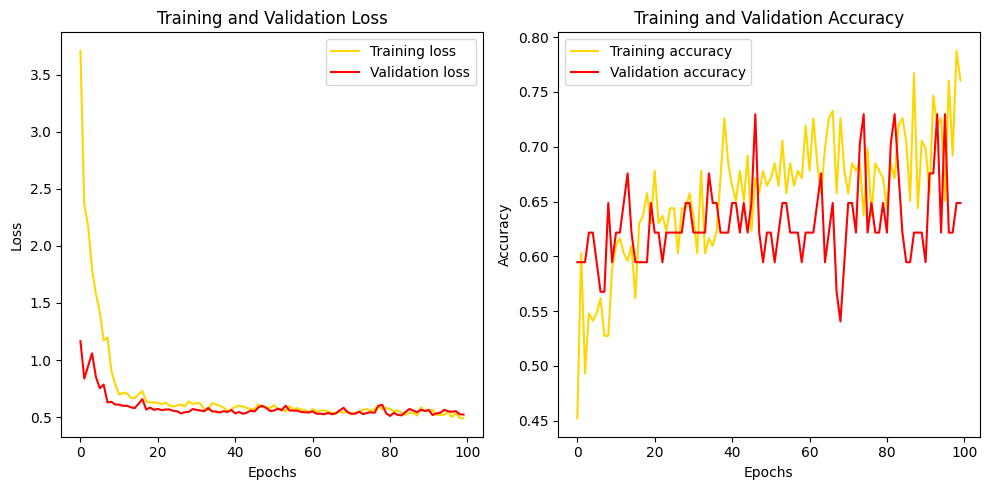

In [ ]:
import keras_tuner as kt
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# Define CNN Model using Hyperparameter Tuning
def build_model(hp):
    model = Sequential()

    # First Conv Layer
    model.add(Conv2D(
        filters=hp.Int('conv1_filters', min_value=16, max_value=64, step=16),
        kernel_size=3,
        activation='relu',
        input_shape=(19, 19, 4)  # Adjust if necessary
    ))
    model.add(MaxPooling2D(pool_size=2))

    # Second Conv Layer
    model.add(Conv2D(
        filters=hp.Int('conv2_filters', min_value=32, max_value=128, step=32),
        kernel_size=3,
        activation='relu'
    ))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Flatten())

    # Dense Layers
    model.add(Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
        activation='relu'
    ))

    # Dropout Layer
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))

    # Output Layer
    model.add(Dense(1, activation='sigmoid'))  # Binary classification

    # Optimizer
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='LOG')
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Define Bayesian Hyperparameter Tuner
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=20,  # Number of different models to try
    directory='tuner_results',
    project_name='flood_cnn_tuning'
)

# Run the tuning process
tuner.search(x_train, y_train, epochs=50, validation_split=0.2, batch_size=16)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
print(f"Conv1 Filters: {best_hps.get('conv1_filters')}")
print(f"Conv2 Filters: {best_hps.get('conv2_filters')}")
print(f"Dense Units: {best_hps.get('dense_units')}")
print(f"Dropout Rate: {best_hps.get('dropout_rate')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

# Train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(x_train, y_train, epochs=100, validation_split=0.2, batch_size=16)

# Save the best model
best_model.save("Best_CNN_262.h5")

# Print final training and validation accuracy/loss
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\nFinal Model Performance:")
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")

# Plot training and validation accuracy/loss
plt.figure(figsize=(10, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', color='gold')
plt.plot(history.history['val_loss'], label='Validation loss', color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy', color='gold')
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color='red')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# ***CNN Model: LeNet5 — Architecture, THIS HAS BEEN MODIFIED USING THE HYPERPARAMETERS GENERATED ABOVE***

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 17, 17, 48)          │           1,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 8, 8, 48)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 6, 6, 32)            │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 3, 3, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 192)                 │          55,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,313 (278.57 KB)

 Trainable params: 71,313 (278.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4171 - loss: 10.5199 - val_accuracy: 0.4324 - val_loss: 6.7790
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4822 - loss: 6.9597 - val_accuracy: 0.4324 - val_loss: 4.7196
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3740 - loss: 7.5618 - val_accuracy: 0.4324 - val_loss: 2.9408
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5276 - loss: 5.3575 - val_accuracy: 0.4865 - val_loss: 1.6500
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5191 - loss: 5.0764 - val_accuracy: 0.5405 - val_loss: 1.0651
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5286 - loss: 3.6656 - val_accuracy: 0.4865 - val_loss: 0.7741
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5280 - loss: 4.1770 - val_accuracy: 0.5946 - val_loss: 0.7835
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4926 - loss: 4.1049 - val_accuracy: 0

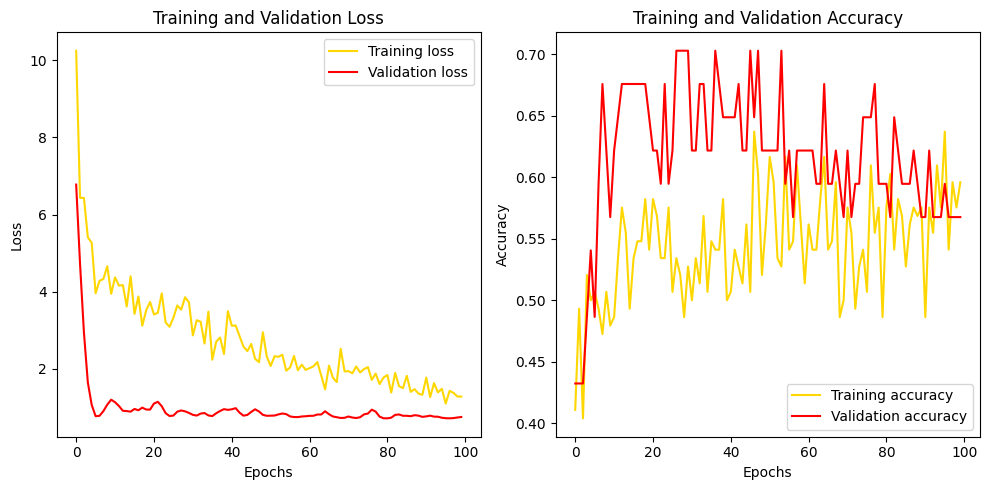

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
import matplotlib.pyplot as plt

# Model Name
NAME = "LeNet_262"

# Assuming image_shape is already defined
input_shape = (19, 19, 4)  # 4 channels (DEM, Landuse, Infiltration, Rainfall)

model = Sequential()

# Layer 1 - Using optimal filters from Bayesian Optimization
model.add(Conv2D(filters=48, kernel_size=3, strides=1, activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=2, strides=2))

# Layer 2 - Using optimal filters
model.add(Conv2D(filters=32, kernel_size=3, strides=1, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

# Flatten layer
model.add(Flatten())

# Fully Connected Layer with optimized neuron count
model.add(Dense(units=192, activation='relu'))

# Dropout Layer with optimized dropout rate
model.add(Dropout(0.4))

# Output Layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Optimizer with optimized learning rate
learning_rate = 0.00001  # Bayesian optimized value
optimizer = Adam(learning_rate=learning_rate)

# Callbacks
checkpoint = ModelCheckpoint("LeNet_262.keras", monitor='val_loss', save_best_only=True, save_freq='epoch')
early = EarlyStopping(monitor='val_loss', patience=200, verbose=1)

tensorboard = TensorBoard(log_dir="logs/{}".format(NAME))

# Compile model
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train the model
history = model.fit(x_train, y_train, batch_size=16, epochs=100, validation_split=0.2, callbacks=[checkpoint, early, tensorboard])

# Save the model
model.save("LeNet_262.keras")

# Print final training and validation accuracy/loss
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\nFinal Model Performance:")
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")

# Plot training and validation accuracy/loss
plt.figure(figsize=(10, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', color='gold')
plt.plot(history.history['val_loss'], label='Validation loss', color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy', color='gold')
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color='red')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


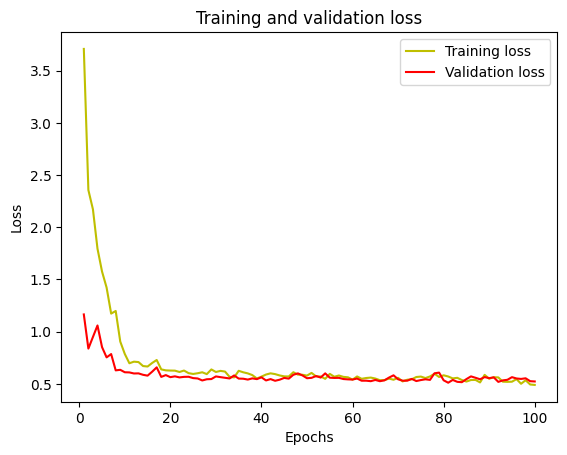

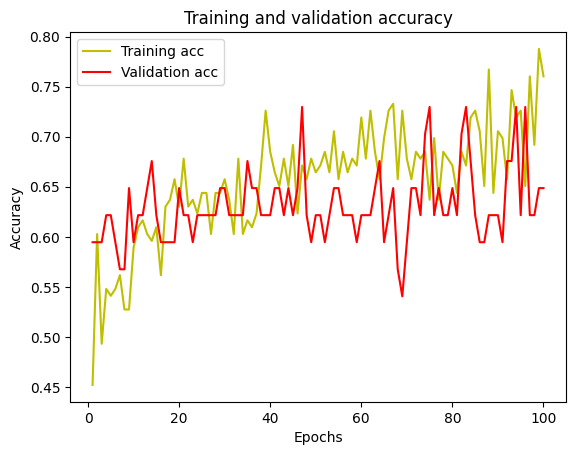

In [ ]:
#plot the training and validation accuracy and loss at each epoch
#plot the training and validation accuracy and loss at each epoch
loss = history.history.get('loss', history.history.get('loss', []))  # Get 'loss' or fallback to 'loss' (for compatibility)
val_loss = history.history.get('val_loss', history.history.get('val_loss', [])) # Get 'val_loss' or fallback to 'val_loss' (for compatibility)
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7153 - loss: 0.4903  
Accuracy =  69.62025165557861 %
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[16 15]
 [ 9 39]]
              precision    recall  f1-score   support

  NotFlooded       0.64      0.52      0.57        31
     Flooded       0.72      0.81      0.76        48

    accuracy                           0.70        79
   macro avg       0.68      0.66      0.67        79
weighted avg       0.69      0.70      0.69        79

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


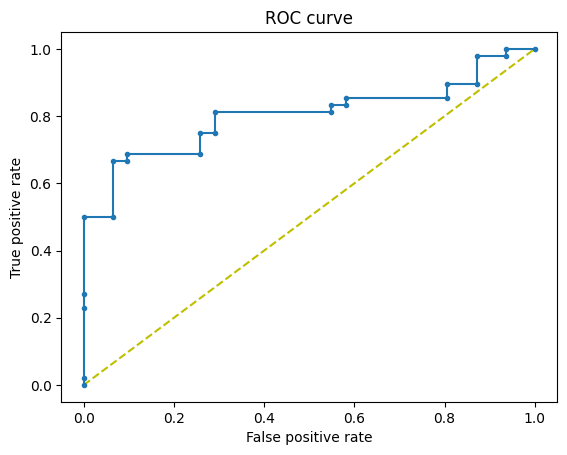

Ideal threshold is:  10    0.637632
Name: thresholds, dtype: float32
Area under curve, AUC =  0.803763440860215


In [ ]:
# Ensure y_test is a NumPy array
y_test = np.array(y_test, dtype=np.int32)  # Convert labels to integer NumPy array

# Replace NaN values in x_test with the mean
x_test_no_nan = np.nan_to_num(x_test, nan=np.nanmean(x_test))

# Load the model
from keras.models import load_model
model = load_model('LeNet_262.keras')

# Now evaluate the model
_, acc = model.evaluate(x_test, y_test)
print("Accuracy = ", (acc * 100.0), "%")

#Confusion matrix
#We compare labels and plot them based on correct or wrong predictions.
#Since sigmoid outputs probabilities we need to apply threshold to convert to label.

mythreshold=0.5
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(x_test)>= mythreshold).astype(int)
cm=confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.metrics import classification_report
target_names = ['NotFlooded', 'Flooded']
print(classification_report(y_test, y_pred, target_names=target_names))

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test, y_pred, labels=None, weights=None)

#Check the confusion matrix for various thresholds. Which one is good?
#Need to balance positive, negative, false positive and false negative.
#ROC can help identify the right threshold.
#Receiver Operating Characteristic (ROC) Curve is a plot that helps us
#visualize the performance of a binary classifier when the threshold is varied.
#ROC

from sklearn.metrics import roc_curve
y_preds = model.predict(x_test).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_preds)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'y--')
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.show()

#One way to find the best threshold once we calculate the true positive
#and false positive rates is ...
#The optimal cut off point would be where “true positive rate” is high
#and the “false positive rate” is low.
#Based on this logic let us find the threshold where tpr-(1-fpr) is zero (or close to 0)
import pandas as pd
i = np.arange(len(tpr))
roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'thresholds' : pd.Series(thresholds, index=i)})
ideal_roc_thresh = roc.iloc[(roc.tf-0).abs().argsort()[:1]]  #Locate the point where the value is close to 0
print("Ideal threshold is: ", ideal_roc_thresh['thresholds'])
#Now use this threshold value in the confusion matrix to visualize the balance
#between tp, fp, fp, and fn

#AUC
#Area under the curve (AUC) for ROC plot can be used to understand how well a classifier is performing.
#% chance that the model can distinguish between positive and negative classes.
from sklearn.metrics import auc
auc_value = auc(fpr, tpr)
print("Area under curve, AUC = ", auc_value)

***PREDICTION MAPPING***

In [ ]:
from keras.models import load_model
model = load_model('LeNet_262.keras')

In [ ]:
Y_predict=model.predict(X_array)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
df_predict = pd.DataFrame()
df_predict['FSM'] = Y_predict.flatten()
df_predict['name'] = y  # ✅ Store labels in 'name' column

# ✅ Fix: Use 'name' instead of 'y'
df_predict['index_ID'] = df_predict['name'].astype(int)

In [ ]:
# # THIS CODE SHOWED THAT THE points SHAPEFILE DOES NOT
# # NOT CONTAIN AN 'index_ID' field, SO I ADDED THAT FIELD TO IT
# # BOTH THE points and df_predict MUST HAVE THAT PARTICULAR COLUMN

# print("df_predict columns:", df_predict.columns)
# print("points columns:", points.columns)


df_predict columns: Index(['FSM', 'name', 'index_ID'], dtype='object')
points columns: Index(['HWMID', 'SURVEYPTNU', 'EVENTNAME', 'EVENTDATE', 'LOCDESCRIP',
       'RECORDERNA', 'RECORDEDDA', 'RECORDINGO', 'SURVEYTECH', 'SURVEYDATE',
       'SURVEYORG', 'FIELDBKID', 'HWMTYPE', 'MARKERSET', 'TRANQUILST',
       'COASTALRIV', 'BANK', 'HGTABOVEGR', 'HWMUNCERTA', 'HWMRATING',
       'HWMDESCRIP', 'HWMELEV', 'HWMELEVCOM', 'HORIZDATUM', 'HORIZSOURC',
       'HORIZSOU_1', 'LAT', 'LONG', 'NORTHING', 'EASTING', 'VERTICALDA',
       'ELEVSOURCE', 'GEOID', 'ELEVSOUR_1', 'SITEBMTYPE', 'SITEBMID',
       'SITEBMDESC', 'GlobalID', 'created_us', 'created_da', 'last_edite',
       'last_edi_1', 'ATTACHMENT', 'FLORNOFL', 'geometry'],
      dtype='object')


In [ ]:
points['index_ID'] = points.index  # Assign unique index as ID
print(points[['index_ID']].head())  # Check if index_ID is created


   index_ID
0         0
1         1
2         2
3         3
4         4


In [ ]:
# MAKING SURE df_predict IS AN INTEGER BEFORE MERGING

df_predict['index_ID'] = df_predict['index_ID'].astype(int)


In [ ]:
FSM_df=pd.merge(points,df_predict,on="index_ID")
FSM_df

,HWMID,SURVEYPTNU,EVENTNAME,EVENTDATE,LOCDESCRIP,RECORDERNA,RECORDEDDA,RECORDINGO,SURVEYTECH,SURVEYDATE,...,created_us,created_da,last_edite,last_edi_1,ATTACHMENT,FLORNOFL,geometry,index_ID,FSM,name
0,KH 21,2023.0,Hurricane Helene,2024-09-26,Side of town house,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327767.75 3116082.565, 327867.75 311...",0,0.902953,0
1,KH 21,2023.0,Hurricane Helene,2024-09-26,Side of town house,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327767.75 3116082.565, 327867.75 311...",0,0.072440,0
2,KH 21,2023.0,Hurricane Helene,2024-09-26,Side of town house,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327767.75 3116082.565, 327867.75 311...",0,0.056447,0
3,KH 21,2023.0,Hurricane Helene,2024-09-26,Side of town house,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327767.75 3116082.565, 327867.75 311...",0,0.148822,0
4,KH 21,2023.0,Hurricane Helene,2024-09-26,Side of town house,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327767.75 3116082.565, 327867.75 311...",0,0.837444,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,KH 22,2024.0,Hurricane Helene,2024-09-26,Front of T-Top store,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327080.464 3115818.838, 327180.464 3...",1,0.993840,1
258,KH 22,2024.0,Hurricane Helene,2024-09-26,Front of T-Top store,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327080.464 3115818.838, 327180.464 3...",1,0.929097,1
259,KH 22,2024.0,Hurricane Helene,2024-09-26,Front of T-Top store,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327080.464 3115818.838, 327180.464 3...",1,0.986913,1
260,KH 22,2024.0,Hurricane Helene,2024-09-26,Front of T-Top store,K Holyoak,2024-09-28,PCDSM,K Holyoak,2024-09-30,...,bcc106432@bcc.pinellas.gov,2024-09-28,bcc106272@bcc.pinellas.gov,2025-01-02,None,1,"POLYGON ((327080.464 3115818.838, 327180.464 3...",1,0.928283,1


***CONVERTING IT TO A SHAPEFILE IF YOU WANT TO LATER CONVERT IT TO RASTER FORMAT USING THE SAHPEFILE IN ARCGIS ***

In [ ]:
# # THIS CONVERTS THE FSM TO A SHAPEFILE AND INDICATES WHERE IT SHOULD BE STORED
# # OTHERWISE, IT WILL BE STORED IN THE CURRENT WORKING DIRECTORY

# output_path = "/content/drive/MyDrive/CNN_262/Final_predictions/FSM.shp"
# FSM_df.to_file(output_path)
# print(f"Shapefile saved at: {output_path}")
#  #This shapefile can be converted to a raster in QGIS or arcmap or by using the python codein the snippet below

Shapefile saved at: /content/drive/MyDrive/CNN/Final_predictions/FSM_1.shp


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field EVENTDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field RECORDEDDA create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field SURVEYDATE create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field created_da create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field last_edi_1 create as date field, though DateTime requested.
  ogr_write(


In [ ]:
print(f"Total Points in FSM_df: {len(FSM_df)}")


Total Points in FSM_df: 262


THE CODE BELOW WAS GENERATED BY GPT TO PERFORM PREDICTION FOR THE ENTIRE AREA. NOTE THAT THIS SECTION TAKES APPROX. 20MINS TO RUN

In [ ]:
import rasterio
import numpy as np
from keras.models import load_model

# Load trained model
model = load_model('LeNet_262.keras')

# Define path to input raster
input_raster_path = "/content/drive/MyDrive/CNN_262/Composite_rasters.tif"

# Load raster data
with rasterio.open(input_raster_path) as src:
    image = src.read()  # Read all bands
    profile = src.profile  # Save profile for writing
    transform = src.transform
    crs = src.crs
    height, width = src.shape  # Get dimensions
    num_bands = image.shape[0]

# Ensure correct shape order (height, width, channels)
image = np.moveaxis(image, 0, -1)  # Change shape from (bands, height, width) to (height, width, bands)

# Define CNN input size based on training patches (modify if needed)
patch_size = 19  # Change this if your model was trained on a different patch size

# Compute number of patches in rows and columns
n_rows = height // patch_size
n_cols = width // patch_size

# Initialize output array for predictions
predicted_map = np.zeros((height, width))

# Loop over raster using sliding window approach
for i in range(n_rows):
    for j in range(n_cols):
        x_start = j * patch_size
        y_start = i * patch_size
        x_end = x_start + patch_size
        y_end = y_start + patch_size

        # Extract patch
        patch = image[y_start:y_end, x_start:x_end, :]

        # Ensure patch matches model input
        if patch.shape[:2] == (patch_size, patch_size):
            patch = np.expand_dims(patch, axis=0)  # Add batch dimension

            # Predict flood susceptibility
            prediction = model.predict(patch, verbose=0)

            # Assign prediction to output map (assuming single-value output per patch)
            predicted_map[y_start:y_end, x_start:x_end] = prediction

# Save as a raster
output_raster_path = "/content/drive/MyDrive/CNN_262/COLAB/Final_predictions/Flood_suscept262.tif"
with rasterio.open(
    output_raster_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=rasterio.float32,
    crs=crs,
    transform=transform
) as dst:
    dst.write(predicted_map, 1)  # Write output prediction

print(f"✅ Flood susceptibility map saved at {output_raster_path}")


✅ Flood susceptibility map saved at /content/drive/MyDrive/CNN_262/COLAB/Final_predictions/Flood_suscept262.tif


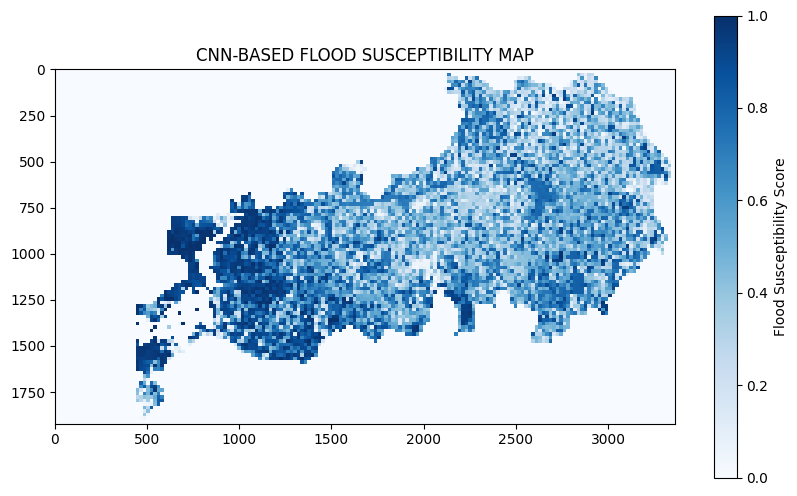

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Path to the saved flood susceptibility map
predicted_map_path = "/content/drive/MyDrive/CNN_262/COLAB/Final_predictions/Flood_suscept262.tif"

# Load the predicted raster
with rasterio.open(predicted_map_path) as src:
    predicted_map = src.read(1)  # Read the first (only) band
    transform = src.transform
    crs = src.crs

# Set up the figure
plt.figure(figsize=(10, 6))

# Change 'cmap' to test different color schemes
plt.imshow(predicted_map, cmap='Blues', interpolation='nearest')  # Try 'terrain', 'coolwarm', 'RdYlBu'

# Add colorbar and labels
plt.colorbar(label="Flood Susceptibility Score")
plt.title("CNN-BASED FLOOD SUSCEPTIBILITY MAP")
#plt.xlabel("X Coordinate")
#plt.ylabel("Y Coordinate")

# Show the map
plt.show()
